# Original Data EDA

EDA using raw ICU stay, admission, and patient files.

## Imports and Paths

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

EDA_OUTPUT_DIR = PROCESSED_DATA_DIR / "eda_outputs"
FIGURE_OUTPUT_DIR = EDA_OUTPUT_DIR / "figures"
EDA_OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Raw data: {RAW_DATA_DIR}")
print(f"EDA outputs: {EDA_OUTPUT_DIR}")

Raw data: /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/raw
EDA outputs: /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs


## Load Original Data

Raw source files: `icustays.csv`, `admissions.csv`, and `patients.csv`.

In [2]:
icustays_raw_df = pd.read_csv(RAW_DATA_DIR / "icustays.csv")
admissions_raw_df = pd.read_csv(RAW_DATA_DIR / "admissions.csv")
patients_raw_df = pd.read_csv(RAW_DATA_DIR / "patients.csv")

print(f"icustays: {icustays_raw_df.shape}")
print(f"admissions: {admissions_raw_df.shape}")
print(f"patients: {patients_raw_df.shape}")

icustays_raw_df.head()

icustays: (94458, 8)
admissions: (546028, 16)
patients: (364627, 6)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


## Merge Descriptive Raw Columns

In [3]:
admission_cols = [
    "subject_id",
    "hadm_id",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "hospital_expire_flag",
]
patient_cols = ["subject_id", "gender", "anchor_age", "anchor_year_group"]

eda_df = (
    icustays_raw_df
    .merge(admissions_raw_df[admission_cols], on=["subject_id", "hadm_id"], how="left")
    .merge(patients_raw_df[patient_cols], on="subject_id", how="left")
)

eda_df["intime"] = pd.to_datetime(eda_df["intime"], errors="coerce")
eda_df["outtime"] = pd.to_datetime(eda_df["outtime"], errors="coerce")
eda_df["los_days"] = pd.to_numeric(eda_df["los"], errors="coerce")
eda_df["los_hours"] = eda_df["los_days"] * 24
eda_df["valid_los"] = eda_df["los_days"].notna() & eda_df["los_days"].gt(0)

age_bins = [0, 18, 40, 60, 80, np.inf]
age_labels = ["<18", "18-39", "40-59", "60-79", "80+"]
eda_df["age_group"] = pd.cut(eda_df["anchor_age"], bins=age_bins, labels=age_labels, right=False)

print(eda_df.shape)
eda_df.head()

(94458, 22)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admission_type,admission_location,...,marital_status,race,hospital_expire_flag,gender,anchor_age,anchor_year_group,los_days,los_hours,valid_los,age_group
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,EW EMER.,EMERGENCY ROOM,...,WIDOWED,WHITE,0,F,52,2014 - 2016,0.410266,9.846389,True,40-59
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,EW EMER.,EMERGENCY ROOM,...,WIDOWED,WHITE,0,F,86,2008 - 2010,3.893252,93.438056,True,80+
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,EW EMER.,EMERGENCY ROOM,...,MARRIED,BLACK/AFRICAN AMERICAN,0,F,73,2008 - 2010,0.497535,11.940833,True,60-79
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,EW EMER.,EMERGENCY ROOM,...,MARRIED,WHITE,0,F,55,2011 - 2013,1.118032,26.832778,True,40-59
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,DIRECT EMER.,PHYSICIAN REFERRAL,...,MARRIED,WHITE,0,F,55,2011 - 2013,0.948113,22.754722,True,40-59


## Raw Data Quality Snapshot

In [4]:
quality_summary_df = pd.DataFrame(
    [
        {"check": "raw_icu_stay_rows", "value": len(eda_df)},
        {"check": "unique_stay_ids", "value": eda_df["stay_id"].nunique()},
        {"check": "duplicate_stay_ids", "value": int(eda_df["stay_id"].duplicated().sum())},
        {"check": "missing_los", "value": int(eda_df["los_days"].isna().sum())},
        {"check": "non_positive_los", "value": int(eda_df["los_days"].le(0).sum())},
        {"check": "missing_outtime", "value": int(eda_df["outtime"].isna().sum())},
        {"check": "missing_admission_metadata", "value": int(eda_df["admission_type"].isna().sum())},
        {"check": "missing_patient_metadata", "value": int(eda_df["gender"].isna().sum())},
    ]
)

quality_summary_df.to_csv(EDA_OUTPUT_DIR / "original_data_quality_summary.csv", index=False)
quality_summary_df

,check,value
0,raw_icu_stay_rows,94458
1,unique_stay_ids,94458
2,duplicate_stay_ids,0
3,missing_los,14
4,non_positive_los,0
5,missing_outtime,14
6,missing_admission_metadata,0
7,missing_patient_metadata,0


## ICU LOS Distribution

Raw LOS and log-transformed LOS shown side by side.

In [5]:
valid_los_df = eda_df[eda_df["valid_los"]].copy()
los_p99 = valid_los_df["los_days"].quantile(0.99)
los_summary = valid_los_df["los_days"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print(los_summary)
los_summary.to_csv(EDA_OUTPUT_DIR / "original_los_summary.csv")

count    94444.000000
mean         3.630025
std          5.402474
min          0.001250
1%           0.209321
5%           0.543570
25%          1.096212
50%          1.965648
75%          3.862575
90%          7.920927
95%         12.681538
99%         26.438372
max        226.403079
Name: los_days, dtype: float64


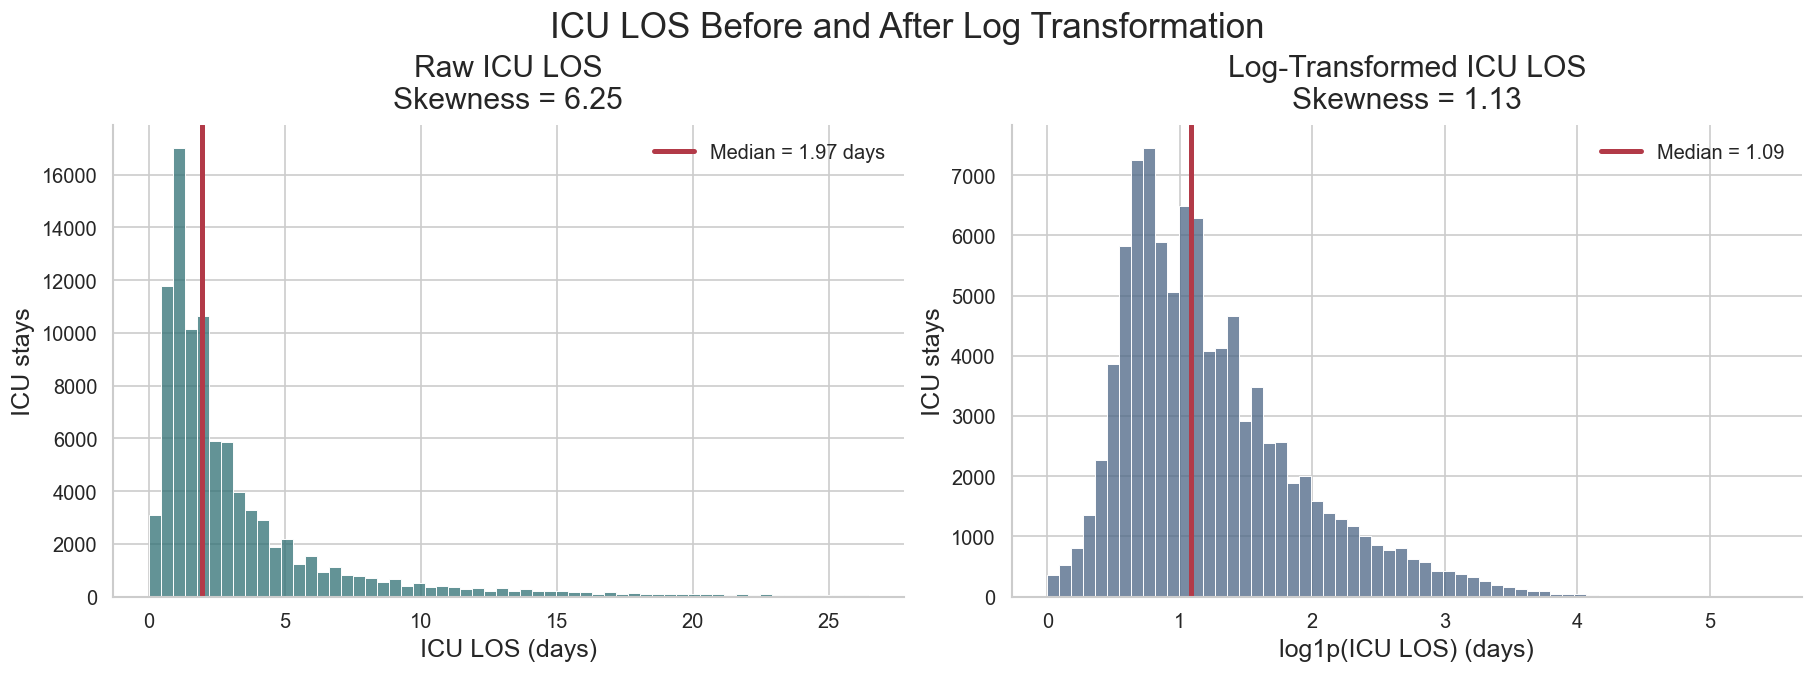

In [6]:
raw_los_skew = valid_los_df["los_days"].skew()
valid_los_df["log1p_los_days"] = np.log1p(valid_los_df["los_days"])
log_los_skew = valid_los_df["log1p_los_days"].skew()

plot_los_df = valid_los_df[valid_los_df["los_days"].le(los_p99)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

sns.histplot(
    data=plot_los_df,
    x="los_days",
    bins=60,
    color="#2f6f73",
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(
    valid_los_df["los_days"].median(),
    color="#b23a48",
    linewidth=3,
    label=f"Median = {valid_los_df['los_days'].median():.2f} days",
)
axes[0].set_title(f"Raw ICU LOS\nSkewness = {raw_los_skew:.2f}", fontsize=18, pad=10)
axes[0].set_xlabel("ICU LOS (days)", fontsize=15)
axes[0].set_ylabel("ICU stays", fontsize=15)
axes[0].tick_params(axis="both", labelsize=12)
axes[0].legend(frameon=False, fontsize=12, loc="upper right")

sns.histplot(
    data=valid_los_df,
    x="log1p_los_days",
    bins=60,
    color="#4b6584",
    edgecolor="white",
    ax=axes[1],
)
axes[1].axvline(
    valid_los_df["log1p_los_days"].median(),
    color="#b23a48",
    linewidth=3,
    label=f"Median = {valid_los_df['log1p_los_days'].median():.2f}",
)
axes[1].set_title(f"Log-Transformed ICU LOS\nSkewness = {log_los_skew:.2f}", fontsize=18, pad=10)
axes[1].set_xlabel("log1p(ICU LOS) (days)", fontsize=15)
axes[1].set_ylabel("ICU stays", fontsize=15)
axes[1].tick_params(axis="both", labelsize=12)
axes[1].legend(frameon=False, fontsize=12, loc="upper right")

fig.suptitle("ICU LOS Before and After Log Transformation", fontsize=21)
sns.despine()
fig.savefig(FIGURE_OUTPUT_DIR / "poster_los_raw_vs_log_histograms.png", bbox_inches="tight")
plt.show()


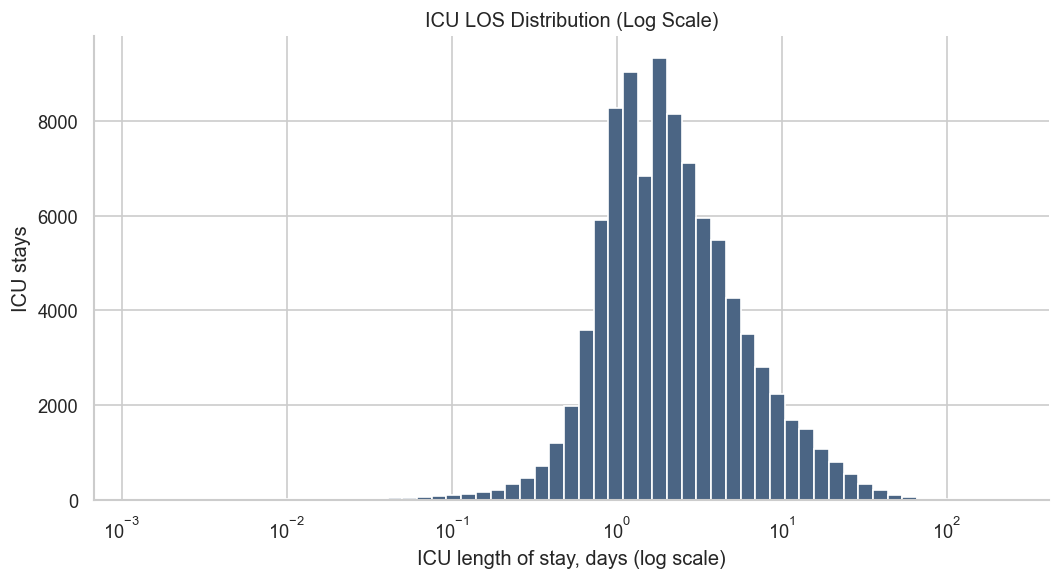

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
log_bins = np.logspace(
    np.log10(valid_los_df["los_days"].min()),
    np.log10(valid_los_df["los_days"].max()),
    60,
)
ax.hist(valid_los_df["los_days"], bins=log_bins, color="#4b6584", edgecolor="white")
ax.set_xscale("log")
ax.set_title("ICU LOS Distribution (Log Scale)")
ax.set_xlabel("ICU length of stay, days (log scale)")
ax.set_ylabel("ICU stays")
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "original_los_distribution_log_scale.png", bbox_inches="tight")
plt.show()

## ICU LOS Categories

Short: <2 days. Medium: 2-7 days. Long: >7 days.

In [8]:
los_category_labels = ["Short (<2 days)", "Medium (2-7 days)", "Long (>7 days)"]
valid_los_df["los_category"] = np.select(
    [
        valid_los_df["los_days"].lt(2),
        valid_los_df["los_days"].between(2, 7, inclusive="both"),
        valid_los_df["los_days"].gt(7),
    ],
    los_category_labels,
    default="Unknown",
)
valid_los_df["los_category"] = pd.Categorical(
    valid_los_df["los_category"],
    categories=los_category_labels,
    ordered=True,
)

los_category_summary_df = (
    valid_los_df["los_category"]
    .value_counts(sort=False)
    .rename_axis("los_category")
    .reset_index(name="stays")
)
los_category_summary_df["pct"] = los_category_summary_df["stays"] / los_category_summary_df["stays"].sum()
los_category_summary_df["label"] = los_category_summary_df.apply(
    lambda row: f"{row['stays']:,}\n({row['pct']:.1%})",
    axis=1,
)

los_category_summary_df.to_csv(EDA_OUTPUT_DIR / "original_los_category_summary.csv", index=False)
los_category_summary_df


,los_category,stays,pct,label
0,Short (<2 days),48107,0.509371,"48,107\n(50.9%)"
1,Medium (2-7 days),35166,0.372348,"35,166\n(37.2%)"
2,Long (>7 days),11171,0.118282,"11,171\n(11.8%)"


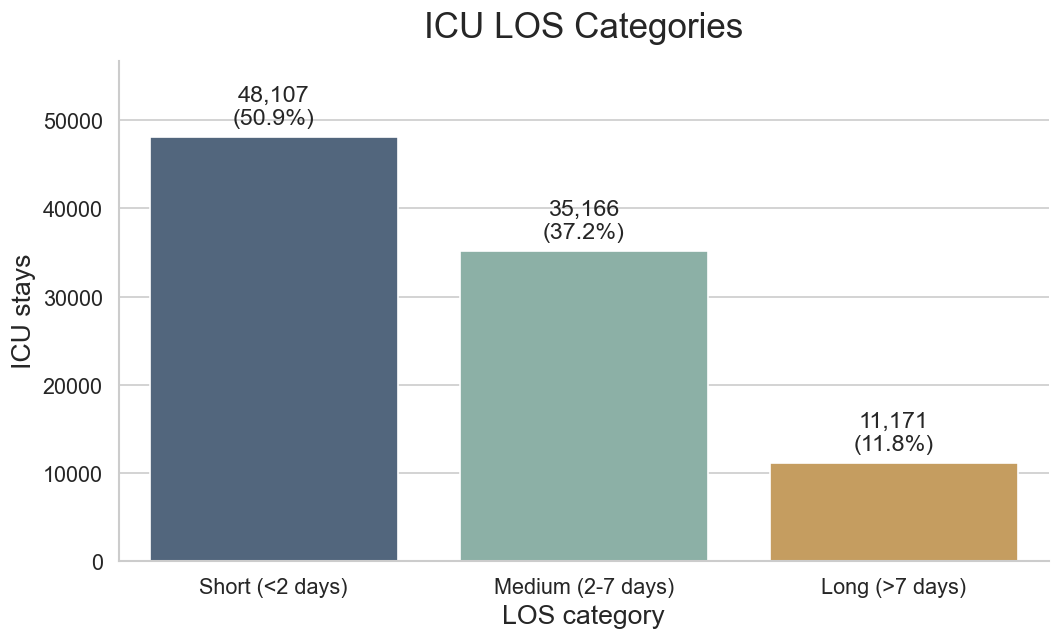

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = ["#4b6584", "#86b6a8", "#d6a04f"]
sns.barplot(
    data=los_category_summary_df,
    x="los_category",
    y="stays",
    order=los_category_labels,
    palette=bar_colors,
    hue="los_category",
    hue_order=los_category_labels,
    legend=False,
    ax=ax,
)

for patch, label in zip(ax.patches, los_category_summary_df["label"]):
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + los_category_summary_df["stays"].max() * 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=14,
    )

ax.set_title("ICU LOS Categories", fontsize=21, pad=14)
ax.set_xlabel("LOS category", fontsize=16)
ax.set_ylabel("ICU stays", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.set_ylim(0, los_category_summary_df["stays"].max() * 1.18)
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "poster_los_categories.png", bbox_inches="tight")
plt.show()


## ICU LOS by First Care Unit

Poster-ready comparison across high-volume ICU care units.

In [10]:
careunit_counts = valid_los_df["first_careunit"].value_counts()
poster_careunits = careunit_counts[careunit_counts.ge(1000)].index.tolist()

careunit_label_map = {
    "Medical Intensive Care Unit (MICU)": "MICU",
    "Medical/Surgical Intensive Care Unit (MICU/SICU)": "MICU/SICU",
    "Cardiac Vascular Intensive Care Unit (CVICU)": "CVICU",
    "Surgical Intensive Care Unit (SICU)": "SICU",
    "Coronary Care Unit (CCU)": "CCU",
    "Trauma SICU (TSICU)": "TSICU",
    "Neuro Intermediate": "Neuro Intermed.",
    "Neuro Surgical Intensive Care Unit (Neuro SICU)": "Neuro SICU",
    "Neuro Stepdown": "Neuro Stepdown",
}

careunit_summary_df = (
    valid_los_df
    .groupby("first_careunit")
    .agg(
        rows=("stay_id", "size"),
        median_los_days=("los_days", "median"),
        mean_los_days=("los_days", "mean"),
        p90_los_days=("los_days", lambda x: x.quantile(0.90)),
        p95_los_days=("los_days", lambda x: x.quantile(0.95)),
    )
    .sort_values("median_los_days", ascending=False)
    .reset_index()
)

poster_careunit_summary_df = careunit_summary_df[careunit_summary_df["first_careunit"].isin(poster_careunits)].copy()
poster_careunit_order = poster_careunit_summary_df.sort_values("median_los_days", ascending=False)["first_careunit"].tolist()
poster_careunit_summary_df["careunit_short"] = poster_careunit_summary_df["first_careunit"].map(careunit_label_map).fillna(poster_careunit_summary_df["first_careunit"])

careunit_summary_df.to_csv(EDA_OUTPUT_DIR / "original_los_by_first_careunit.csv", index=False)
poster_careunit_summary_df.to_csv(EDA_OUTPUT_DIR / "poster_los_by_first_careunit.csv", index=False)
poster_careunit_summary_df


,first_careunit,rows,median_los_days,mean_los_days,p90_los_days,p95_los_days,careunit_short
5,Neuro Intermediate,5776,2.998304,5.021332,11.308490,16.741343,Neuro Intermed.
7,Neuro Surgical Intensive Care Unit (Neuro SICU),1750,2.237975,4.480323,10.738968,16.110157,Neuro SICU
8,Neuro Stepdown,1421,2.197350,4.065212,8.966574,13.991817,Neuro Stepdown
9,Coronary Care Unit (CCU),10771,2.012685,3.094193,6.590336,9.242442,CCU
11,Cardiac Vascular Intensive Care Unit (CVICU),14769,1.992095,3.317241,6.234313,10.144419,CVICU
12,Surgical Intensive Care Unit (SICU),13008,1.977187,3.901684,8.698779,13.801186,SICU
13,Medical Intensive Care Unit (MICU),20699,1.912187,3.758191,8.787231,13.416039,MICU
14,Trauma SICU (TSICU),10474,1.883113,3.642700,8.278103,13.754148,TSICU
15,Medical/Surgical Intensive Care Unit (MICU/SICU),15447,1.786146,3.091032,6.529880,10.402873,MICU/SICU


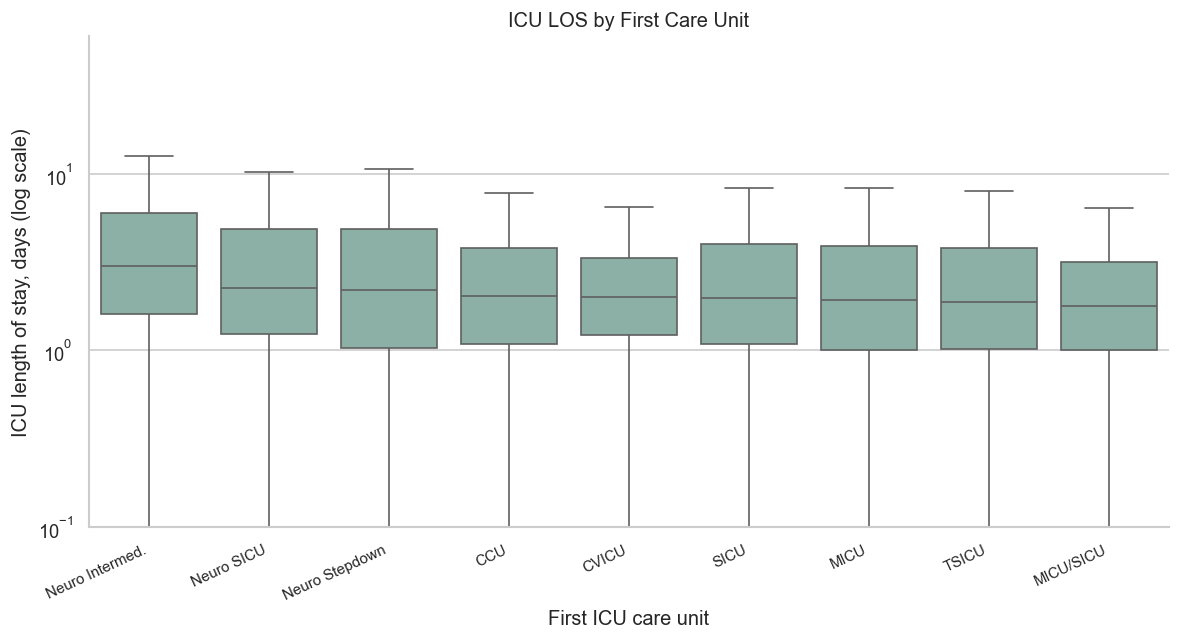

In [11]:
poster_careunit_plot_df = valid_los_df[valid_los_df["first_careunit"].isin(poster_careunit_order)].copy()
poster_careunit_plot_df["careunit_short"] = poster_careunit_plot_df["first_careunit"].map(careunit_label_map).fillna(poster_careunit_plot_df["first_careunit"])
short_order = [careunit_label_map.get(unit, unit) for unit in poster_careunit_order]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(
    data=poster_careunit_plot_df,
    x="careunit_short",
    y="los_days",
    order=short_order,
    showfliers=False,
    color="#86b6a8",
    linewidth=1,
    ax=ax,
)
ax.set_yscale("log")
ax.set_ylim(0.1, 60)
ax.set_title("ICU LOS by First Care Unit")
ax.set_xlabel("First ICU care unit")
ax.set_ylabel("ICU length of stay, days (log scale)")
ax.tick_params(axis="x", rotation=25, labelsize=9)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "poster_los_by_first_careunit_log_boxplot.png", bbox_inches="tight")
plt.show()


## LOS by Admission Type

In [12]:
admission_type_order = (
    valid_los_df
    .groupby("admission_type")["los_days"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

admission_type_summary_df = (
    valid_los_df
    .groupby("admission_type")
    .agg(
        rows=("stay_id", "size"),
        median_los_days=("los_days", "median"),
        mean_los_days=("los_days", "mean"),
        p90_los_days=("los_days", lambda x: x.quantile(0.90)),
    )
    .sort_values("median_los_days", ascending=False)
    .reset_index()
)

admission_type_summary_df.to_csv(EDA_OUTPUT_DIR / "original_los_by_admission_type.csv", index=False)
admission_type_summary_df

,admission_type,rows,median_los_days,mean_los_days,p90_los_days
0,URGENT,15374,2.269867,4.407848,9.844144
1,OBSERVATION ADMIT,14031,2.112431,3.824740,8.200370
2,DIRECT EMER.,3316,2.080174,3.769731,8.168339
3,ELECTIVE,3027,1.960324,3.088629,5.993215
4,EW EMER.,48349,1.912431,3.543752,7.968843
5,SURGICAL SAME DAY ADMISSION,9544,1.681730,2.869612,5.188373
6,AMBULATORY OBSERVATION,25,0.836667,0.886184,1.845875
7,DIRECT OBSERVATION,237,0.793993,0.924400,1.370449
8,EU OBSERVATION,541,0.719028,1.085947,1.503750


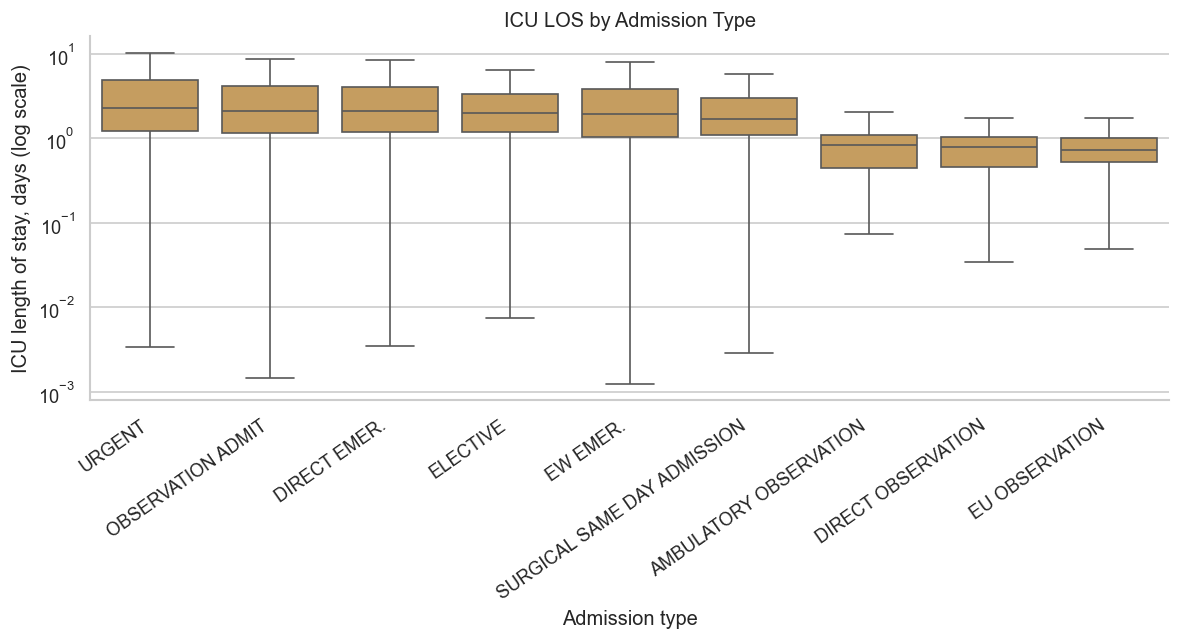

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(
    data=valid_los_df,
    x="admission_type",
    y="los_days",
    order=admission_type_order,
    showfliers=False,
    color="#d6a04f",
    linewidth=1,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("ICU LOS by Admission Type")
ax.set_xlabel("Admission type")
ax.set_ylabel("ICU length of stay, days (log scale)")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "original_los_by_admission_type_log_boxplot.png", bbox_inches="tight")
plt.show()

## Age and ICU LOS

In [14]:
age_group_summary_df = (
    valid_los_df
    .groupby("age_group", observed=True)
    .agg(
        rows=("stay_id", "size"),
        median_los_days=("los_days", "median"),
        mean_los_days=("los_days", "mean"),
        p90_los_days=("los_days", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

age_group_summary_df.to_csv(EDA_OUTPUT_DIR / "original_los_by_age_group.csv", index=False)
age_group_summary_df

,age_group,rows,median_los_days,mean_los_days,p90_los_days
0,18-39,9573,1.732708,3.519375,7.566794
1,40-59,26214,1.933351,3.749947,8.501120
2,60-79,42159,2.035961,3.734289,8.123338
3,80+,16498,1.967257,3.237247,6.887838


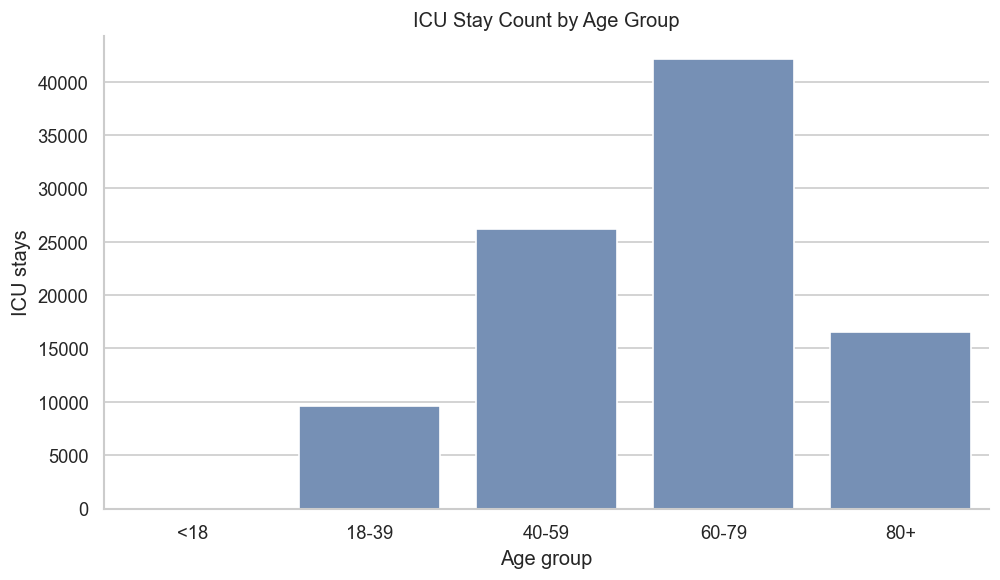

In [15]:
fig, ax1 = plt.subplots(figsize=(8.5, 5))
bar_data = age_group_summary_df.copy()
sns.barplot(data=bar_data, x="age_group", y="rows", color="#6c8ebf", ax=ax1)
ax1.set_title("ICU Stay Count by Age Group")
ax1.set_xlabel("Age group")
ax1.set_ylabel("ICU stays")
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "original_icu_stays_by_age_group.png", bbox_inches="tight")
plt.show()

## Raw Cohort Composition

In [16]:
composition_tables = {}
for col in ["first_careunit", "admission_type", "gender", "race", "insurance", "age_group"]:
    table = (
        valid_los_df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="rows")
    )
    table["row_pct"] = table["rows"] / len(valid_los_df)
    composition_tables[col] = table
    table.to_csv(EDA_OUTPUT_DIR / f"original_composition_{col}.csv", index=False)

composition_tables["first_careunit"].head(15)

,first_careunit,rows,row_pct
0,Medical Intensive Care Unit (MICU),20699,0.219167
1,Medical/Surgical Intensive Care Unit (MICU/SICU),15447,0.163557
2,Cardiac Vascular Intensive Care Unit (CVICU),14769,0.156378
3,Surgical Intensive Care Unit (SICU),13008,0.137732
4,Coronary Care Unit (CCU),10771,0.114046
5,Trauma SICU (TSICU),10474,0.110902
6,Neuro Intermediate,5776,0.061158
7,Neuro Surgical Intensive Care Unit (Neuro SICU),1750,0.018529
8,Neuro Stepdown,1421,0.015046
9,Surgery/Vascular/Intermediate,145,0.001535


## Summary Points

In [17]:
poster_takeaways = [
    f"Raw ICU stays: {len(eda_df):,}; positive LOS stays: {len(valid_los_df):,}.",
    f"Median LOS: {valid_los_df['los_days'].median():.2f} days; 99th percentile: {valid_los_df['los_days'].quantile(0.99):.2f} days.",
    "LOS is strongly right-skewed.",
    "LOS differs by first care unit and admission type.",
]

poster_takeaways_df = pd.DataFrame({"takeaway": poster_takeaways})
poster_takeaways_df.to_csv(EDA_OUTPUT_DIR / "poster_eda_takeaways.csv", index=False)
for takeaway in poster_takeaways:
    print(f"- {takeaway}")

- Raw ICU stays: 94,458; positive LOS stays: 94,444.
- Median LOS: 1.97 days; 99th percentile: 26.44 days.
- LOS is strongly right-skewed.
- LOS differs by first care unit and admission type.


## Saved Outputs

In [18]:
print("Saved EDA tables:")
for path in sorted(EDA_OUTPUT_DIR.glob("*.csv")):
    print(f"- {path}")

print("\nSaved figures:")
for path in sorted(FIGURE_OUTPUT_DIR.glob("*.png")):
    print(f"- {path}")


Saved EDA tables:
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_admission_type.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_age_group.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_first_careunit.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_gender.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_insurance.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_composition_race.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_data_quality_summary.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival_Analysis/data/processed/eda_outputs/original_los_by_admission_type.csv
- /Users/brandonwu/Documents/ICU_LOS_Survival